# T1 – Tic Tac Toe com ML | Árvore de Decisão

**Objetivo:** classificar o estado de um tabuleiro em *Tem jogo*, *X venceu*, *O venceu* ou *Empate*.

**Como funciona:** a árvore de decisão aprende uma sequência de perguntas sobre as features (por exemplo, "a vez é do X?"). Cada pergunta divide os exemplos em dois grupos, escolhida de forma a deixar cada grupo o mais "puro" possível (com uma classe predominante). A previsão é a classe majoritária da folha onde o tabuleiro termina.

> Requer na mesma pasta: `preprocessamento.py`, `treino.csv`, `validacao.csv`, `teste.csv`.

## 1. Configuração dos experimentos

- **Semente fixa (42):** os resultados são reproduzíveis.
- **Critério de escolha:** **F1 macro** na validação (média do F1 de cada classe). Diferente da acurácia, ele não deixa a classe *Empate*, com poucos exemplos, ser ignorada.
- **Métricas finais:** acurácia, precision, recall e F1 (macro), medidas no teste uma única vez.
- **Desempate:** entre configurações com o mesmo F1 na validação, escolhe-se a árvore com menos folhas (mais simples).

In [22]:
import itertools
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score,
                             precision_score, recall_score)
from sklearn.tree import DecisionTreeClassifier, plot_tree

from pathlib import Path

RAIZ = next(
    pasta for pasta in [Path.cwd(), *Path.cwd().parents]
    if (pasta / 'dataset').is_dir()
)

def carregar(abordagem):
    pasta = RAIZ / 'dataset' / f'abordagem_{abordagem}'

    saida = []

    for nome in ['treino', 'validacao', 'teste']:
        df = pd.read_csv(pasta / f'{nome}.csv')

        X = df.drop(columns=['classe'])
        y = df['classe']

        saida.extend([X, y])

    return saida

SEMENTE = 42
ABORDAGENS = [1, 2]

GRADE = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None],
}


def metricas(y_real, y_pred):
    """As 4 métricas pedidas no enunciado (média macro entre as classes)."""
    return {
        "acuracia": accuracy_score(y_real, y_pred),
        "precision": precision_score(y_real, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_real, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_real, y_pred, average="macro", zero_division=0),
    }

## 2. Carregamento e preparação dos dados

Todos os algoritmos do grupo utilizam os mesmos conjuntos de dados, divididos em treino, validação e teste, com semente fixa. Os arquivos são carregados diretamente das pastas `dataset/abordagem_1` e `dataset/abordagem_2`.

- **Abordagem 1 (9 features):** representa as nove posições do tabuleiro, com `x = 1`, `o = -1` e vazio `= 0`.
- **Abordagem 2 (15 features):** utiliza características extraídas do tabuleiro, como quantidade de X e O, posições ocupadas, linhas com exatamente dois símbolos iguais, casas vazias e jogador da vez.

**Balanceamento:** o conjunto original de treinamento possui 430 exemplos. Para reduzir o desbalanceamento entre as quatro classes, são utilizados os arquivos de treinamento preparados pelo grupo, com *oversampling* da classe Empate, totalizando 560 registros. Os conjuntos de validação e teste permanecem com 93 exemplos cada.

**Normalização:** não é necessária, porque algoritmos baseados em árvores realizam divisões a partir dos valores de cada atributo e não dependem da escala das características.

In [23]:
dados = {ab: carregar(ab) for ab in ABORDAGENS}

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, Xte, yte = dados[ab]
    print(f"Abordagem {ab}: {Xtr.shape[1]} features | "
          f"treino={len(Xtr)}, validação={len(Xval)}, teste={len(Xte)}")

pd.DataFrame({nome: y.value_counts() for nome, y in
              [("treino", dados[1][1]), ("validacao", dados[1][3]), ("teste", dados[1][5])]})

Abordagem 1: 9 features | treino=560, validação=93, teste=93
Abordagem 2: 15 features | treino=560, validação=93, teste=93


,treino,validacao,teste
classe,,,
Empate,140,3,3
O venceu,140,30,30
Tem jogo,140,30,30
X venceu,140,30,30


## 3. Treinamento e validação da Árvore de Decisão

Para cada abordagem, são testadas 64 combinações de parâmetros (2 × 8 × 4 × 1). Cada combinação é treinada no treino e medida na validação. A melhor é retreinada e guardada para a avaliação final.

In [24]:
buscas, melhores_params, modelos, tempos = {}, {}, {}, {}

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, _, _ = dados[ab]

    tentativas = []
    for valores in itertools.product(*GRADE.values()):
        params = dict(zip(GRADE.keys(), valores))
        m = DecisionTreeClassifier(random_state=SEMENTE, **params).fit(Xtr, ytr)
        tentativas.append({**params,
                           "f1_treino": f1_score(ytr, m.predict(Xtr), average="macro"),
                           "f1_val": f1_score(yval, m.predict(Xval), average="macro"),
                           "folhas": m.get_n_leaves()})
    tabela = pd.DataFrame(tentativas)
    tabela.to_csv(f"arvore_busca_abordagem{ab}.csv", index=False)
    buscas[ab] = tabela

    # Melhor F1 na validação; em empate, a árvore com menos folhas
    melhor = tabela.sort_values(["f1_val", "folhas"], ascending=[False, True]).iloc[0]
    params = {k: (None if pd.isna(melhor[k]) else melhor[k]) for k in GRADE}
    if params["max_depth"] is not None:
        params["max_depth"] = int(params["max_depth"])
    params["min_samples_leaf"] = int(params["min_samples_leaf"])
    melhores_params[ab] = params

    # Modelo final (medindo o tempo de treino)
    t0 = time.perf_counter()
    modelos[ab] = DecisionTreeClassifier(random_state=SEMENTE, **params).fit(Xtr, ytr)
    tempos[ab] = (time.perf_counter() - t0) * 1000

    print(f"Abordagem {ab}: {params} | F1 treino = {melhor.f1_treino:.3f} | "
          f"F1 validação = {melhor.f1_val:.3f}")

Abordagem 1: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 1, 'class_weight': None} | F1 treino = 0.961 | F1 validação = 0.644
Abordagem 2: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 1, 'class_weight': None} | F1 treino = 0.982 | F1 validação = 0.975


### 3.1 Justificativa dos parâmetros

| Parâmetro | Valores testados | O que controla / por que testar |
|---|---|---|
| `criterion` | gini, entropy | Medida de impureza usada para escolher cada divisão. As duas são as mais usadas e costumam dar resultados parecidos; testamos ambas para confirmar. |
| `max_depth` | 2 a 10, sem limite | Profundidade máxima. É o principal controle de **overfitting**: árvores muito profundas "decoram" o treino. |
| `min_samples_leaf` | 1, 2, 5, 10 | Mínimo de exemplos por folha. Valores maiores impedem folhas criadas para um único exemplo. |
| `class_weight` | None | Não foram aplicados pesos adicionais às classes, pois o conjunto de treinamento já foi balanceado por oversampling.|

Parâmetros escolhidos pela validação:

In [25]:
pd.DataFrame(melhores_params).T.rename_axis("abordagem")

,criterion,max_depth,min_samples_leaf,class_weight
abordagem,,,,
1,gini,8,1,None
2,gini,6,1,None


### 3.2 Análise de overfitting

Mantendo os demais parâmetros escolhidos, o gráfico mostra o F1 no treino e na validação conforme a profundidade máxima aumenta. Quando o treino continua subindo e a validação para de melhorar, o modelo está decorando o treino.

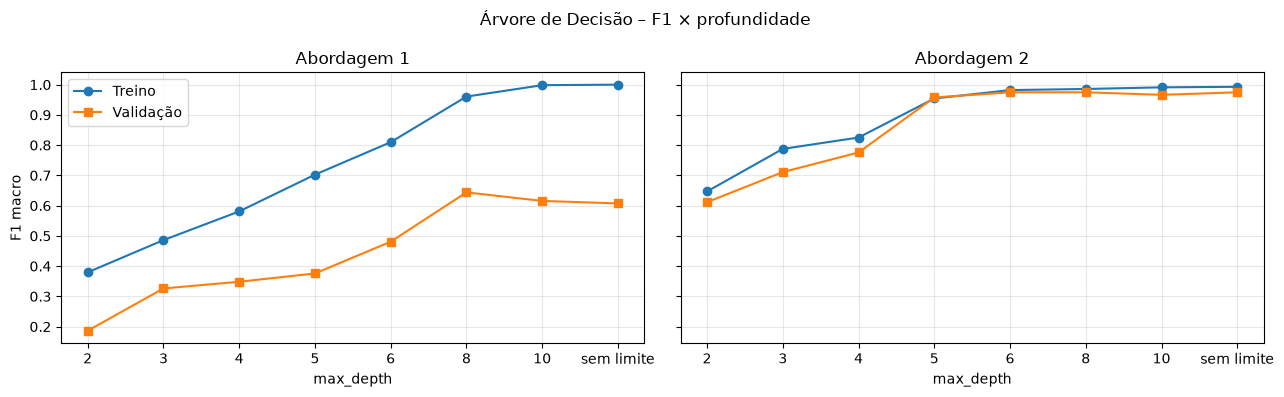

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, ab in zip(axes, ABORDAGENS):
    p, t = melhores_params[ab], buscas[ab]
    curva = t[(t.criterion == p["criterion"])
              & (t.min_samples_leaf == p["min_samples_leaf"])
              & (t.class_weight.fillna("None") == str(p["class_weight"]))].copy()
    curva["max_depth"] = curva["max_depth"].fillna(99).astype(int)
    curva = curva.sort_values("max_depth")
    rotulos = [str(d) if d != 99 else "sem limite" for d in curva.max_depth]
    ax.plot(rotulos, curva.f1_treino, "o-", label="Treino")
    ax.plot(rotulos, curva.f1_val, "s-", label="Validação")
    ax.set_title(f"Abordagem {ab}")
    ax.set_xlabel("max_depth")
    ax.grid(alpha=.3)

axes[0].set_ylabel("F1 macro")
axes[0].legend()
fig.suptitle("Árvore de Decisão – F1 × profundidade")
fig.tight_layout()
fig.savefig("arvore_overfitting.png", dpi=150)
plt.show()

### 3.3 Interpretação dos resultados de overfitting

- **Abordagem 1:** apresenta sinais de overfitting. O modelo alcança um desempenho elevado no treinamento, mas apresenta resultados inferiores na validação. Isso indica dificuldade para generalizar as regras do jogo utilizando apenas as nove posições do tabuleiro.

- **Abordagem 2:** apresenta melhor capacidade de generalização. As características extraídas do tabuleiro facilitam a identificação dos padrões necessários para classificar o estado do jogo, permitindo obter resultados elevados com uma árvore menos complexa.

A comparação mostra que a representação dos dados influencia diretamente o desempenho e a complexidade da Árvore de Decisão.

## 4. Resultados dos experimentos

### 4.1 Comparação entre as abordagens

Desempenho dos modelos escolhidos na **validação**, com o tamanho da árvore e o custo de treino.

In [27]:
linhas = []

for ab in ABORDAGENS:
    Xtr, ytr, Xval, yval, _, _ = dados[ab]
    m = modelos[ab]

    linhas.append({
        "abordagem": ab,
        "n_features": Xtr.shape[1],
        **metricas(yval, m.predict(Xval)),
        "profundidade": m.get_depth(),
        "folhas": m.get_n_leaves(),
        "tempo_treino_ms": tempos[ab]
    })

comparacao_val = pd.DataFrame(linhas).set_index("abordagem")

print(comparacao_val.round(4))

melhor_abordagem = comparacao_val["f1"].idxmax()

print(f"Melhor abordagem: {melhor_abordagem}")
print(f"F1 macro: {comparacao_val.loc[melhor_abordagem, 'f1']:.4f}")

           n_features  acuracia  precision  recall      f1  profundidade  \
abordagem                                                                  
1                   9    0.6882     0.7631  0.6083  0.6438             8   
2                  15    0.9677     0.9763  0.9750  0.9747             6   

           folhas  tempo_treino_ms  
abordagem                           
1             115           0.9542  
2              21           0.9885  
Melhor abordagem: 2
F1 macro: 0.9747


### 4.2 Gráfico comparativo

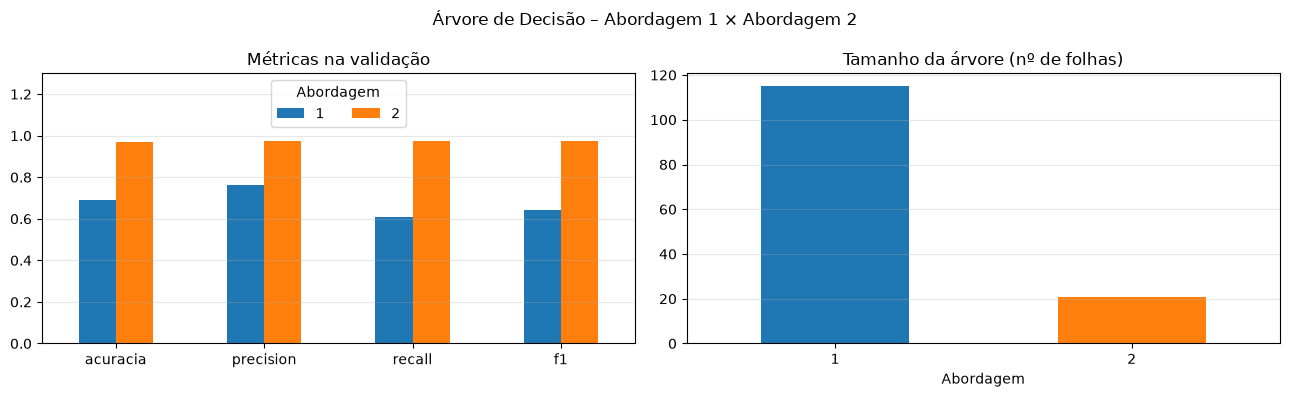

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

comparacao_val[["acuracia", "precision", "recall", "f1"]].T.plot.bar(ax=axes[0], rot=0)
axes[0].set_title("Métricas na validação")
axes[0].set_ylim(0, 1.3)
axes[0].legend(title="Abordagem", loc="upper center", ncol=2)
axes[0].grid(axis="y", alpha=.3)

comparacao_val["folhas"].plot.bar(ax=axes[1], rot=0, color=["tab:blue", "tab:orange"])
axes[1].set_title("Tamanho da árvore (nº de folhas)")
axes[1].set_xlabel("Abordagem")
axes[1].grid(axis="y", alpha=.3)

fig.suptitle("Árvore de Decisão – Abordagem 1 × Abordagem 2")
fig.tight_layout()
fig.savefig("arvore_comparativo.png", dpi=150)
plt.show()

### 4.3 Avaliação no conjunto de teste

Avaliação **única** dos modelos escolhidos, em tabuleiros que não foram usados nem para treinar nem para escolher parâmetros. Os modelos são salvos (`.joblib`) para uso no front end.

===== Abordagem 1 =====
              precision    recall  f1-score   support

      Empate       0.00      0.00      0.00         3
    O venceu       0.62      0.70      0.66        30
    Tem jogo       0.64      0.53      0.58        30
    X venceu       0.74      0.77      0.75        30

    accuracy                           0.65        93
   macro avg       0.50      0.50      0.50        93
weighted avg       0.65      0.65      0.64        93

===== Abordagem 2 =====
              precision    recall  f1-score   support

      Empate       1.00      1.00      1.00         3
    O venceu       1.00      1.00      1.00        30
    Tem jogo       1.00      0.87      0.93        30
    X venceu       0.88      1.00      0.94        30

    accuracy                           0.96        93
   macro avg       0.97      0.97      0.97        93
weighted avg       0.96      0.96      0.96        93



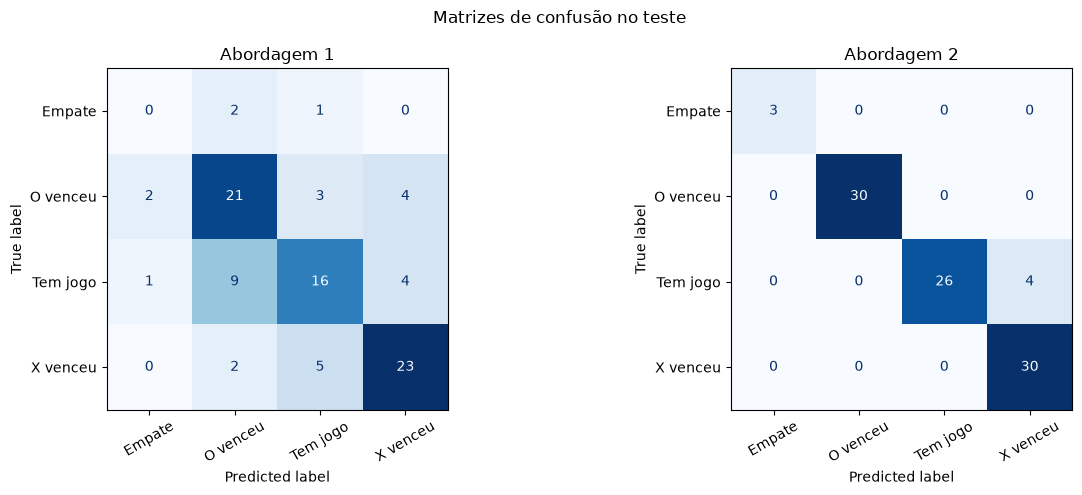

,abordagem,acuracia,precision,recall,f1,folhas,tempo_treino_ms
0,1,0.645,0.500,0.500,0.498,115,0.954
1,2,0.957,0.971,0.967,0.967,21,0.988


In [29]:
resultados_teste = []
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, ab in zip(axes, ABORDAGENS):
    _, _, _, _, Xte, yte = dados[ab]
    m = modelos[ab]
    t0 = time.perf_counter()
    pred = m.predict(Xte)
    tempo_pred = (time.perf_counter() - t0) * 1000

    print(f"===== Abordagem {ab} =====")
    print(classification_report(yte, pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(yte, pred, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(f"Abordagem {ab}")
    ax.tick_params(axis="x", rotation=30)

    resultados_teste.append({"abordagem": ab, **melhores_params[ab], **metricas(yte, pred),
                             "profundidade": m.get_depth(), "folhas": m.get_n_leaves(),
                             "tempo_treino_ms": tempos[ab], "tempo_pred_ms": tempo_pred})
    joblib.dump(m, f"arvore_modelo_ab{ab}.joblib")

fig.suptitle("Matrizes de confusão no teste")
fig.tight_layout()
fig.savefig("arvore_matriz_confusao.png", dpi=150)
plt.show()

resultados_teste = pd.DataFrame(resultados_teste)
resultados_teste.to_csv("arvore_resultados_teste.csv", index=False)
resultados_teste[["abordagem", "acuracia", "precision", "recall", "f1",
                  "folhas", "tempo_treino_ms"]].round(3)

### 4.4 Análise dos resultados

- **A Abordagem 2 apresenta desempenho superior:** o F1 macro na validação foi de 0,9747, contra 0,6438 da Abordagem 1. A acurácia também aumentou de 0,6882 para 0,9677.

- **A representação dos dados facilita o aprendizado:** enquanto a Abordagem 1 utiliza diretamente as nove posições do tabuleiro, a Abordagem 2 fornece características que resumem informações importantes sobre o estado do jogo.

- **Complexidade:** a árvore da Abordagem 2 possui 21 folhas, contra 115 da Abordagem 1. Isso demonstra que o modelo conseguiu alcançar melhor desempenho com uma estrutura mais simples.

**Generalização:** a Abordagem 2 manteve um desempenho elevado no conjunto de teste, alcançando F1 macro de 0,967, próximo ao resultado de 0,975 obtido na validação. Já a Abordagem 1 apresentou F1 macro de 0,498 no teste, inferior aos 0,644 da validação. Esses resultados reforçam a importância da representação dos dados para a capacidade de generalização do modelo.

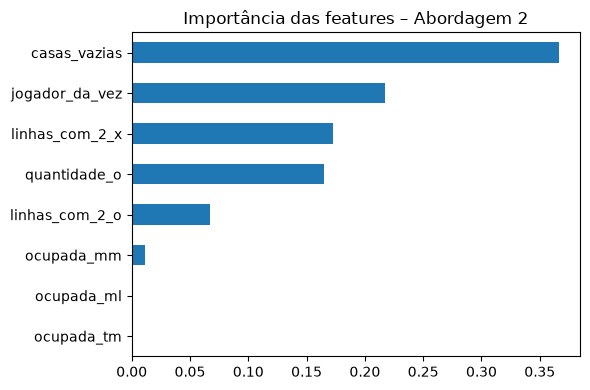

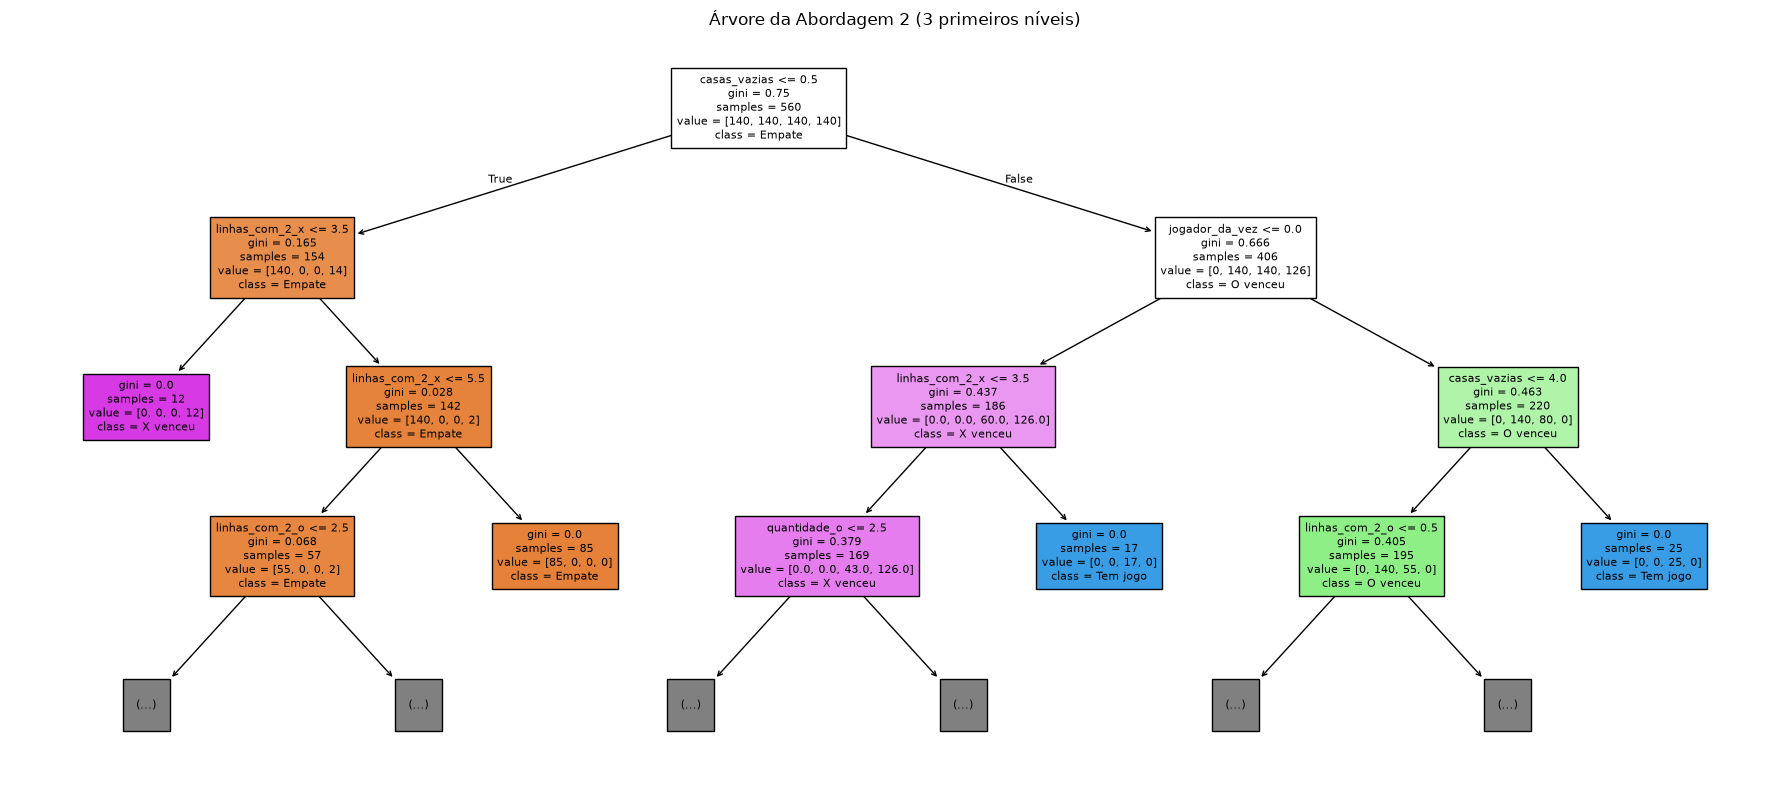

In [30]:
imp = pd.Series(modelos[2].feature_importances_, dados[2][0].columns).sort_values()
imp[imp > 0].plot.barh(figsize=(6, 4), title="Importância das features – Abordagem 2")
plt.tight_layout()
plt.savefig("arvore_importancia_ab2.png", dpi=150)
plt.show()

plt.figure(figsize=(18, 8))
plot_tree(modelos[2], feature_names=list(dados[2][0].columns),
          class_names=modelos[2].classes_, filled=True, max_depth=3, fontsize=8)
plt.title("Árvore da Abordagem 2 (3 primeiros níveis)")
plt.tight_layout()
plt.savefig("arvore_desenho_ab2.png", dpi=150)
plt.show()

- **Desempenho:** a Abordagem 2 apresentou resultados superiores no conjunto de teste, alcançando F1 macro de 0,967, contra 0,498 da Abordagem 1. A acurácia aumentou de 64,52% para 95,70%.

- **Características relevantes:** as características `casas_vazias`, `jogador_da_vez` e `linhas_com_2_x` estão entre as mais importantes para a classificação, pois fornecem informações sobre o andamento da partida e as possibilidades de vitória.

- **Empate:** a Abordagem 1 não identificou corretamente nenhum dos três empates presentes no teste, enquanto a Abordagem 2 identificou todos. Como essa classe possui apenas três exemplos no teste, os resultados devem ser interpretados com cautela.

- **Complexidade:** a árvore da Abordagem 2 possui 21 folhas, contra 115 da Abordagem 1, apresentando uma estrutura mais simples e melhor desempenho.

## 5. Conclusão

A Abordagem 2 é mais adequada para a Árvore de Decisão: apresentou melhor desempenho na validação (F1 macro de 0,9747 contra 0,6438), com uma árvore aproximadamente cinco vezes menor (21 folhas contra 115).

A árvore sozinha não consegue resolver tão bem a Abordagem 1, porque reconhecer três símbolos em linha a partir de casas isoladas exige combinar muitas perguntas. Isso explica a maior complexidade da árvore e os sinais de overfitting observados.

A principal vantagem da árvore é a interpretabilidade: é possível visualizar as regras que ela aprendeu. A principal limitação é a tendência ao overfitting quando as características não resumem bem o problema.